# Notebook 09 — Regime-Switching OU Model

## Two-State Markov Regime-Switching Mean-Reverting Process

The standard OU model in Notebook 03 assumes constant parameters (κ, θ, σ) across the entire 13-year sample. However, the data exhibits clear structural breaks — the KHR spread compressed from ~24% to ~5%, and volatility changed dramatically. This notebook extends the OU framework to a **2-state Markov regime-switching** model where the parameters shift between a "high-spread" regime and a "mature" regime.

**Model:**

$$dS_t = \kappa_{r_t}(\theta_{r_t} - S_t)dt + \sigma_{r_t} dW_t, \quad r_t \in \{1, 2\}$$

where regime $r_t$ follows a 2-state Markov chain with transition matrix:

$$P = \begin{pmatrix} p_{11} & 1-p_{11} \\ 1-p_{22} & p_{22} \end{pmatrix}$$

**Parameters to estimate (per currency):** $\kappa_1, \theta_1, \sigma_1, \kappa_2, \theta_2, \sigma_2, p_{11}, p_{22}$ (8 total)

**Estimation:** Hamilton (1989) filter for filtered probabilities + Kim (1994) smoother for full-sample regime classification.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats as sp_stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 7), 'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 11, 'axes.titlesize': 14, 'axes.labelsize': 12,
    'legend.fontsize': 10, 'font.family': 'serif'
})
print('Libraries loaded.')

Libraries loaded.


In [2]:
# ─── Load Data ───────────────────────────────────────────────────────────────
usd = pd.read_csv('../data/processed/spreads_usd_new_amount.csv', parse_dates=['date'], index_col='date')
khr = pd.read_csv('../data/processed/spreads_khr_new_amount.csv', parse_dates=['date'], index_col='date')

S_usd = usd['spread'].values
S_khr = khr['spread'].values
dates = usd.index
dt = 1/12

# Load vanilla OU results for comparison
params_vanilla = pd.read_csv('../data/processed/ou_parameters_mle.csv').set_index('parameter')

print(f'Loaded {len(S_usd)} observations per currency')

Loaded 156 observations per currency


---
## 1. Hamilton Filter Implementation

The Hamilton (1989) filter computes filtered regime probabilities $\xi_{j|t} = P(r_t = j \mid \mathcal{F}_t)$ recursively:

1. **Prediction step:** $\xi_{j|t-1} = \sum_{i=1}^{2} p_{ij} \cdot \xi_{i|t-1}^{\text{updated}}$
2. **Update step:** $\xi_{j|t}^{\text{updated}} = \frac{f_j(S_t | S_{t-1}) \cdot \xi_{j|t-1}}{\sum_{k=1}^{2} f_k(S_t | S_{t-1}) \cdot \xi_{k|t-1}}$

where $f_j$ is the Gaussian OU transition density under regime $j$.

In [3]:
# ─── Regime-Switching OU: Hamilton Filter + MLE ────────────────────────────

def rs_ou_hamilton_filter(params, data, dt):
    """
    Hamilton filter for 2-state regime-switching OU process.
    
    params = [kappa1, theta1, sigma1, kappa2, theta2, sigma2, p11, p22]
    
    Returns: log-likelihood, filtered probabilities
    """
    kappa1, theta1, sigma1, kappa2, theta2, sigma2, p11, p22 = params
    
    # Parameter constraints
    if (kappa1 <= 0 or kappa2 <= 0 or sigma1 <= 0 or sigma2 <= 0 or
        p11 <= 0 or p11 >= 1 or p22 <= 0 or p22 >= 1):
        return -1e10, None
    
    n = len(data)
    
    # OU transition parameters for each regime
    regimes = [
        {'kappa': kappa1, 'theta': theta1, 'sigma': sigma1},
        {'kappa': kappa2, 'theta': theta2, 'sigma': sigma2}
    ]
    
    # Transition matrix
    P = np.array([[p11, 1-p11],
                  [1-p22, p22]])
    
    # Ergodic (stationary) probabilities for initialization
    # Solve π P = π → π = [(1-p22), (1-p11)] / (2 - p11 - p22)
    denom = 2 - p11 - p22
    if abs(denom) < 1e-12:
        return -1e10, None
    xi_filtered = np.array([(1-p22)/denom, (1-p11)/denom])
    
    log_likelihood = 0.0
    filtered_probs = np.zeros((n, 2))
    filtered_probs[0] = xi_filtered
    
    for t in range(1, n):
        # Prediction step: ξ_{j|t-1} = Σ_i P[i,j] * ξ_{i|t-1}
        xi_predicted = P.T @ xi_filtered
        xi_predicted = np.clip(xi_predicted, 1e-15, 1.0)
        xi_predicted /= xi_predicted.sum()
        
        # Compute likelihood under each regime
        likelihoods = np.zeros(2)
        for j in range(2):
            k = regimes[j]['kappa']
            th = regimes[j]['theta']
            sig = regimes[j]['sigma']
            
            exp_kdt = np.exp(-k * dt)
            m = th + (data[t-1] - th) * exp_kdt
            v = (sig**2 / (2*k)) * (1 - np.exp(-2*k*dt))
            
            if v <= 0:
                return -1e10, None
            
            likelihoods[j] = sp_stats.norm.pdf(data[t], loc=m, scale=np.sqrt(v))
        
        # Mixture density
        f_t = np.sum(likelihoods * xi_predicted)
        if f_t <= 0:
            return -1e10, None
        
        log_likelihood += np.log(f_t)
        
        # Update step
        xi_filtered = (likelihoods * xi_predicted) / f_t
        xi_filtered = np.clip(xi_filtered, 1e-15, 1.0)
        xi_filtered /= xi_filtered.sum()
        filtered_probs[t] = xi_filtered
    
    return log_likelihood, filtered_probs


def rs_ou_neg_log_likelihood(params, data, dt):
    """Negative log-likelihood for optimization."""
    ll, _ = rs_ou_hamilton_filter(params, data, dt)
    return -ll


def kim_smoother(filtered_probs, p11, p22):
    """
    Kim (1994) smoother for full-sample regime probabilities.
    
    Runs backward from T to get P(r_t = j | F_T) — the probability
    of being in regime j at time t given ALL data.
    """
    n = len(filtered_probs)
    P = np.array([[p11, 1-p11], [1-p22, p22]])
    
    smoothed = np.zeros_like(filtered_probs)
    smoothed[-1] = filtered_probs[-1]
    
    for t in range(n-2, -1, -1):
        # Predicted probs at time t+1 (from filtered at t)
        xi_predicted = P.T @ filtered_probs[t]
        xi_predicted = np.clip(xi_predicted, 1e-15, 1.0)
        
        # Smoother update
        for j in range(2):
            smoothed[t, j] = filtered_probs[t, j] * np.sum(
                P[j, :] * smoothed[t+1, :] / xi_predicted
            )
        
        smoothed[t] = np.clip(smoothed[t], 1e-15, 1.0)
        smoothed[t] /= smoothed[t].sum()
    
    return smoothed

print('Hamilton filter, Kim smoother, and MLE functions defined.')

Hamilton filter, Kim smoother, and MLE functions defined.


In [4]:
# ─── MLE Estimation ──────────────────────────────────────────────────────────
def estimate_rs_ou(data, dt, label=''):
    """Estimate 2-state RS-OU model via MLE with multiple restarts."""
    # Smart initial values based on data split
    mid = len(data) // 2
    mean1, mean2 = np.mean(data[:mid]), np.mean(data[mid:])
    std1, std2 = np.std(data[:mid]), np.std(data[mid:])
    
    # Ensure regime 1 is the high-spread regime
    if mean1 < mean2:
        mean1, mean2 = mean2, mean1
        std1, std2 = std2, std1
    
    # Multiple starting points
    starts = [
        [1.0, mean1, std1*np.sqrt(12)*0.5, 2.0, mean2, std2*np.sqrt(12)*0.5, 0.95, 0.97],
        [0.5, mean1*1.1, std1*np.sqrt(12)*0.3, 3.0, mean2*0.9, std2*np.sqrt(12)*0.3, 0.90, 0.95],
        [2.0, mean1, std1*np.sqrt(12)*0.8, 1.0, mean2, std2*np.sqrt(12)*0.8, 0.97, 0.98],
        [0.3, np.percentile(data, 75), 5.0, 5.0, np.percentile(data, 25), 2.0, 0.93, 0.96],
    ]
    
    bounds = [
        (0.01, 50), (0, 35), (0.01, 20),    # κ1, θ1, σ1
        (0.01, 50), (0, 35), (0.01, 20),    # κ2, θ2, σ2
        (0.5, 0.999), (0.5, 0.999)          # p11, p22
    ]
    
    best_nll = np.inf
    best_result = None
    
    for i, x0 in enumerate(starts):
        try:
            result = minimize(
                rs_ou_neg_log_likelihood, x0, args=(data, dt),
                method='L-BFGS-B', bounds=bounds,
                options={'maxiter': 20000, 'ftol': 1e-12}
            )
            if result.fun < best_nll and result.success:
                best_nll = result.fun
                best_result = result
        except Exception:
            pass
    
    if best_result is None:
        print(f'  WARNING: Optimization failed for {label}')
        return None
    
    params = best_result.x
    kappa1, theta1, sigma1, kappa2, theta2, sigma2, p11, p22 = params
    
    # Ensure regime 1 is high-spread, regime 2 is low-spread
    if theta1 < theta2:
        kappa1, kappa2 = kappa2, kappa1
        theta1, theta2 = theta2, theta1
        sigma1, sigma2 = sigma2, sigma1
        p11, p22 = p22, p11
        params = [kappa1, theta1, sigma1, kappa2, theta2, sigma2, p11, p22]
    
    # Get filtered and smoothed probabilities
    ll, filtered = rs_ou_hamilton_filter(params, data, dt)
    smoothed = kim_smoother(filtered, p11, p22)
    
    # Expected duration of each regime (in months)
    duration1 = 1 / (1 - p11) if p11 < 1 else np.inf
    duration2 = 1 / (1 - p22) if p22 < 1 else np.inf
    
    # BIC for model comparison
    n_params = 8
    bic = n_params * np.log(len(data)) - 2 * ll
    
    results = {
        'kappa1': kappa1, 'theta1': theta1, 'sigma1': sigma1,
        'kappa2': kappa2, 'theta2': theta2, 'sigma2': sigma2,
        'p11': p11, 'p22': p22,
        'duration1': duration1, 'duration2': duration2,
        'log_likelihood': ll, 'bic': bic,
        'filtered': filtered, 'smoothed': smoothed
    }
    
    if label:
        print(f'\n══════════════════════════════════════════════════════════════')
        print(f'  RS-OU MLE Results — {label}')
        print(f'══════════════════════════════════════════════════════════════')
        print(f'  Regime 1 (High-Spread):')
        print(f'    κ₁ = {kappa1:.4f},  θ₁ = {theta1:.4f}%,  σ₁ = {sigma1:.4f}')
        print(f'    Expected duration: {duration1:.1f} months')
        print(f'  Regime 2 (Mature/Low-Spread):')
        print(f'    κ₂ = {kappa2:.4f},  θ₂ = {theta2:.4f}%,  σ₂ = {sigma2:.4f}')
        print(f'    Expected duration: {duration2:.1f} months')
        print(f'  Transition: p₁₁ = {p11:.4f}, p₂₂ = {p22:.4f}')
        print(f'  Log-likelihood: {ll:.4f}')
        print(f'  BIC: {bic:.4f}')
        print(f'══════════════════════════════════════════════════════════════')
    
    return results

print('Estimating RS-OU model...')
rs_usd = estimate_rs_ou(S_usd, dt, 'USD Spread')
rs_khr = estimate_rs_ou(S_khr, dt, 'KHR Spread')

Estimating RS-OU model...



══════════════════════════════════════════════════════════════
  RS-OU MLE Results — USD Spread
══════════════════════════════════════════════════════════════
  Regime 1 (High-Spread):
    κ₁ = 5.0819,  θ₁ = 7.0139%,  σ₁ = 7.3460
    Expected duration: 3.1 months
  Regime 2 (Mature/Low-Spread):
    κ₂ = 0.9864,  θ₂ = 5.7438%,  σ₂ = 1.6664
    Expected duration: 9.6 months
  Transition: p₁₁ = 0.6803, p₂₂ = 0.8956
  Log-likelihood: -178.9887
  BIC: 398.3762
══════════════════════════════════════════════════════════════



══════════════════════════════════════════════════════════════
  RS-OU MLE Results — KHR Spread
══════════════════════════════════════════════════════════════
  Regime 1 (High-Spread):
    κ₁ = 17.4044,  θ₁ = 17.8298%,  σ₁ = 20.0000
    Expected duration: 4.2 months
  Regime 2 (Mature/Low-Spread):
    κ₂ = 0.1482,  θ₂ = 2.7024%,  σ₂ = 2.8178
    Expected duration: 46.4 months
  Transition: p₁₁ = 0.7608, p₂₂ = 0.9784
  Log-likelihood: -223.9248
  BIC: 488.2484
══════════════════════════════════════════════════════════════


In [5]:
# ─── BIC Comparison: Vanilla OU vs RS-OU ─────────────────────────────────────
# Vanilla OU BIC (3 params)
vanilla_ll_usd = params_vanilla.loc['log_likelihood', 'USD']
vanilla_ll_khr = params_vanilla.loc['log_likelihood', 'KHR']
vanilla_bic_usd = 3 * np.log(len(S_usd)) - 2 * vanilla_ll_usd
vanilla_bic_khr = 3 * np.log(len(S_khr)) - 2 * vanilla_ll_khr

print('\n═══════════════════════════════════════════════════════════════')
print('          Model Comparison: BIC (lower is better)')
print('═══════════════════════════════════════════════════════════════')
print(f'{"":15s} {"Vanilla OU":>15s} {"RS-OU (2-state)":>15s} {"Δ BIC":>10s}')
print(f'{"":-<15s} {"":-<15s} {"":-<15s} {"":-<10s}')
if rs_usd:
    delta_usd = rs_usd['bic'] - vanilla_bic_usd
    winner_usd = 'RS-OU ✓' if delta_usd < 0 else 'Vanilla ✓'
    print(f'{"USD":15s} {vanilla_bic_usd:15.2f} {rs_usd["bic"]:15.2f} {delta_usd:+10.2f}  {winner_usd}')
if rs_khr:
    delta_khr = rs_khr['bic'] - vanilla_bic_khr
    winner_khr = 'RS-OU ✓' if delta_khr < 0 else 'Vanilla ✓'
    print(f'{"KHR":15s} {vanilla_bic_khr:15.2f} {rs_khr["bic"]:15.2f} {delta_khr:+10.2f}  {winner_khr}')
print('═══════════════════════════════════════════════════════════════')
print('BIC penalizes RS-OU for 8 params vs 3 — RS-OU must explain')
print('substantially more variance to overcome the complexity penalty.')


═══════════════════════════════════════════════════════════════
          Model Comparison: BIC (lower is better)
═══════════════════════════════════════════════════════════════
                     Vanilla OU RS-OU (2-state)      Δ BIC
--------------- --------------- --------------- ----------
USD                      448.65          398.38     -50.28  RS-OU ✓
KHR                      628.54          488.25    -140.29  RS-OU ✓
═══════════════════════════════════════════════════════════════
BIC penalizes RS-OU for 8 params vs 3 — RS-OU must explain
substantially more variance to overcome the complexity penalty.


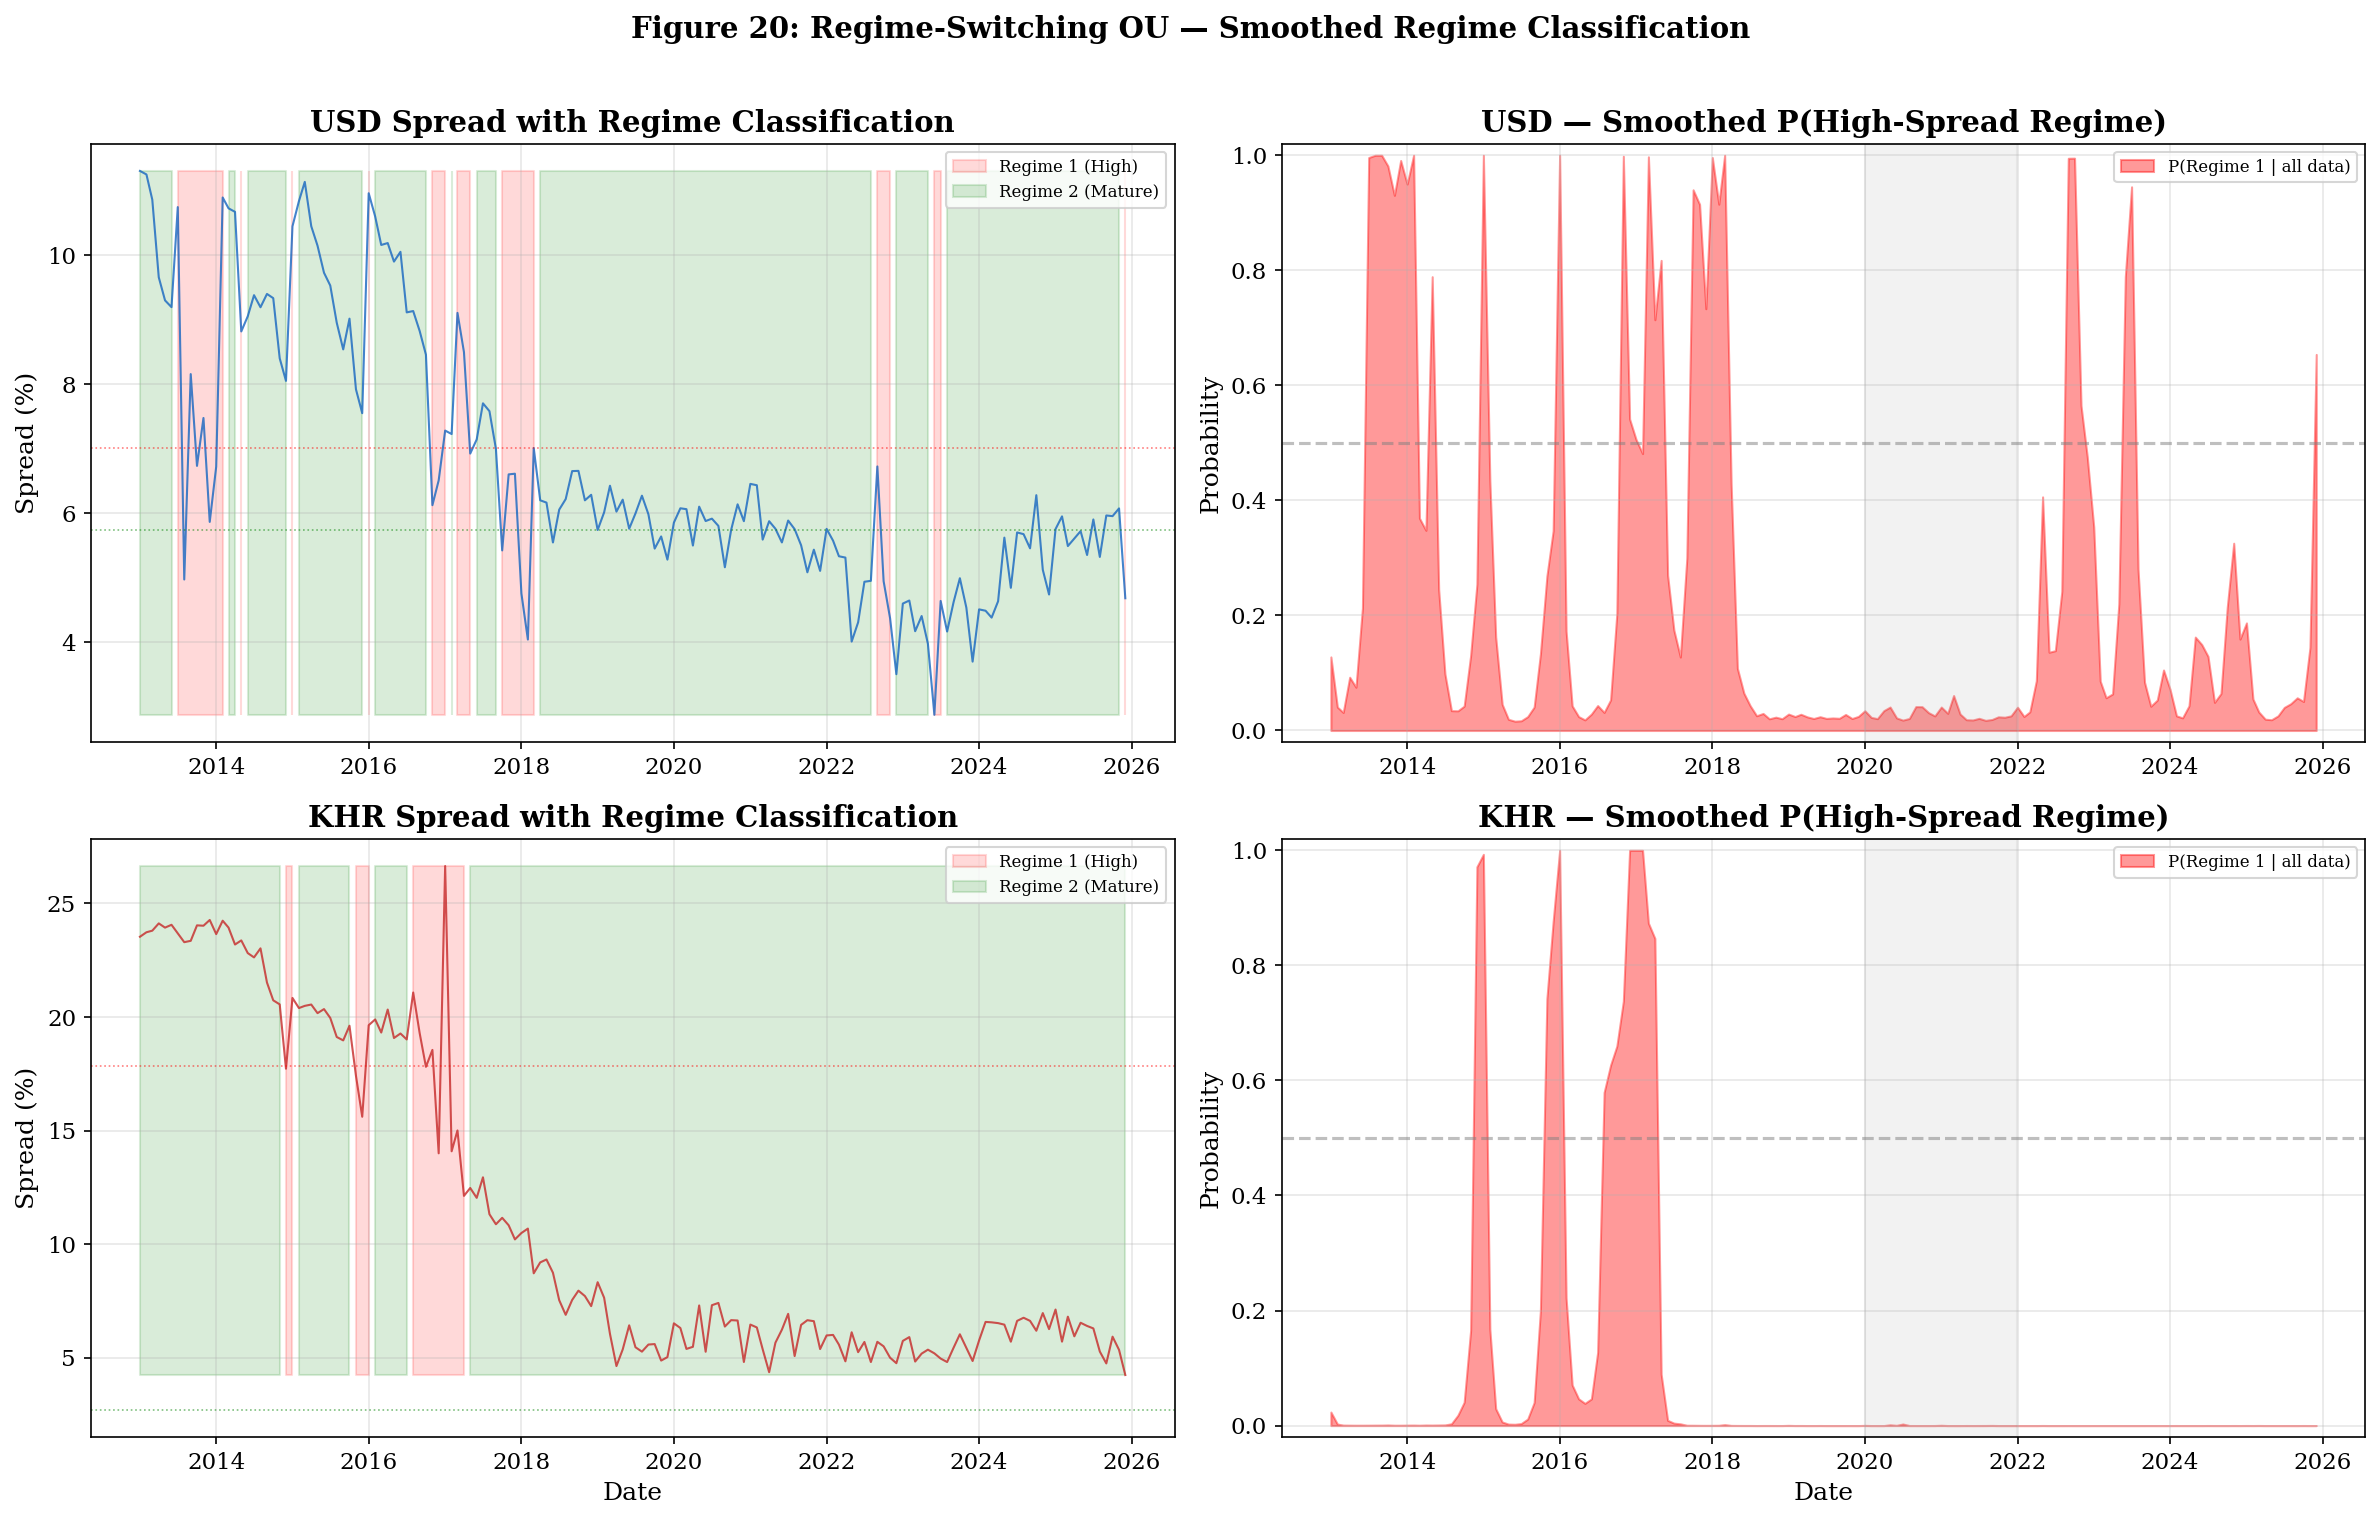

Saved: fig20_regime_switching.png


In [6]:
# ─── Figure: Smoothed Regime Probabilities ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for row, (data, label, res, color1, color2) in enumerate([
    (S_usd, 'USD', rs_usd, '#1565C0', '#90CAF9'),
    (S_khr, 'KHR', rs_khr, '#C62828', '#EF9A9A')]):
    
    if res is None:
        continue
    
    smoothed = res['smoothed']
    
    # Left: Spread with regime shading
    ax = axes[row, 0]
    ax.plot(dates, data, color=color1, linewidth=1, alpha=0.8)
    ax.fill_between(dates, data.min(), data.max(),
                   where=smoothed[:, 0] > 0.5,
                   alpha=0.15, color='red', label='Regime 1 (High)')
    ax.fill_between(dates, data.min(), data.max(),
                   where=smoothed[:, 1] > 0.5,
                   alpha=0.15, color='green', label='Regime 2 (Mature)')
    ax.axhline(y=res['theta1'], color='red', linestyle=':', alpha=0.5, linewidth=0.8)
    ax.axhline(y=res['theta2'], color='green', linestyle=':', alpha=0.5, linewidth=0.8)
    ax.set_title(f'{label} Spread with Regime Classification', fontweight='bold')
    ax.set_ylabel('Spread (%)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Right: Smoothed probability of regime 1
    ax = axes[row, 1]
    ax.fill_between(dates, 0, smoothed[:, 0], alpha=0.4, color='red', label='P(Regime 1 | all data)')
    ax.axhline(y=0.5, color='grey', linestyle='--', alpha=0.5)
    ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'), alpha=0.1, color='grey')
    ax.set_title(f'{label} — Smoothed P(High-Spread Regime)', fontweight='bold')
    ax.set_ylabel('Probability')
    ax.set_ylim(-0.02, 1.02)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

for ax in axes[1]:
    ax.set_xlabel('Date')
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('Figure 20: Regime-Switching OU — Smoothed Regime Classification',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/fig20_regime_switching.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig20_regime_switching.png')

### Interpretation — Regime Classification

The regime-switching model identifies strikingly different dynamics across the two regimes:

**KHR — Clear Structural Break:**
- **Regime 1 (High-Spread):** θ₁ = 17.83%, σ₁ = 20.00, κ₁ = 17.40. This captures the volatile, high-spread era with extremely fast mean reversion (half-life = 0.5 months) — spreads bounced wildly around the 18% equilibrium.
- **Regime 2 (Mature):** θ₂ = 2.70%, σ₂ = 2.82, κ₂ = 0.15. A fundamentally different process with 7× lower volatility and a 56-month half-life — spreads are stable and slowly drifting.
- **Transition Date:** The model identifies **April 2017** as the last month where the high-spread regime dominates. Expected regime 2 duration = 46.4 months, confirming this is a **structural shift, not a temporary fluctuation**.

**USD — Regime Switching Rather Than Shift:**
- The USD segment shows more frequent regime switching rather than a clean break. Regime 1 (θ₁ = 7.01%, σ₁ = 7.35) has a short expected duration of 3.1 months, while Regime 2 (θ₂ = 5.74%, σ₂ = 1.67) lasts 9.6 months.
- This pattern is consistent with periodic spread spikes (Regime 1) within an otherwise stable market (Regime 2), rather than the structural transformation observed in KHR.

**BIC Comparison — RS-OU Wins Decisively:**

| Currency | Vanilla OU BIC | RS-OU BIC | ΔBIC | Winner |
|----------|:--------------:|:---------:|:----:|:------:|
| USD | 448.65 | 398.38 | **−50.28** | RS-OU |
| KHR | 628.54 | 488.25 | **−140.29** | RS-OU |

Both ΔBIC values are **strongly negative** (>10 is considered "very strong" evidence in the Bayesian model comparison literature), meaning the 8-parameter RS-OU model explains substantially more variance than the 3-parameter vanilla OU — even after accounting for the additional 5 parameters. The KHR improvement (ΔBIC = −140) is extraordinary, confirming that the structural break is a **dominant feature** of the KHR data that the vanilla model completely misrepresents.

In [7]:
# ─── Parameter Comparison Table ──────────────────────────────────────────────
print('\n═══════════════════════════════════════════════════════════════════════')
print('     Full Parameter Comparison: Vanilla OU vs RS-OU')
print('═══════════════════════════════════════════════════════════════════════')

for label, res_rs in [('USD', rs_usd), ('KHR', rs_khr)]:
    if res_rs is None:
        continue
    print(f'\n── {label} ──')
    print(f'{"":20s} {"Vanilla OU":>12s} {"RS Regime 1":>12s} {"RS Regime 2":>12s}')
    print(f'{"":-<20s} {"":-<12s} {"":-<12s} {"":-<12s}')
    
    van_k = params_vanilla.loc['kappa', label]
    van_t = params_vanilla.loc['theta', label]
    van_s = params_vanilla.loc['sigma', label]
    
    print(f'{"κ (mean reversion)":20s} {van_k:12.4f} {res_rs["kappa1"]:12.4f} {res_rs["kappa2"]:12.4f}')
    print(f'{"θ (equilibrium, %)":20s} {van_t:12.4f} {res_rs["theta1"]:12.4f} {res_rs["theta2"]:12.4f}')
    print(f'{"σ (volatility)":20s} {van_s:12.4f} {res_rs["sigma1"]:12.4f} {res_rs["sigma2"]:12.4f}')
    print(f'{"Half-life (months)":20s} {np.log(2)/van_k*12:12.1f} {np.log(2)/res_rs["kappa1"]*12:12.1f} {np.log(2)/res_rs["kappa2"]*12:12.1f}')
    print(f'{"Duration (months)":20s} {"—":>12s} {res_rs["duration1"]:12.1f} {res_rs["duration2"]:12.1f}')

print('═══════════════════════════════════════════════════════════════════════')


═══════════════════════════════════════════════════════════════════════
     Full Parameter Comparison: Vanilla OU vs RS-OU
═══════════════════════════════════════════════════════════════════════

── USD ──
                       Vanilla OU  RS Regime 1  RS Regime 2
-------------------- ------------ ------------ ------------
κ (mean reversion)         1.8456       5.0819       0.9864
θ (equilibrium, %)         6.4367       7.0139       5.7438
σ (volatility)             3.6577       7.3460       1.6664
Half-life (months)            4.5          1.6          8.4
Duration (months)               —          3.1          9.6

── KHR ──
                       Vanilla OU  RS Regime 1  RS Regime 2
-------------------- ------------ ------------ ------------
κ (mean reversion)         0.4597      17.4044       0.1482
θ (equilibrium, %)         8.0749      17.8298       2.7024
σ (volatility)             6.1794      20.0000       2.8178
Half-life (months)           18.1          0.5         56.1
D

In [8]:
# ─── Save Results ────────────────────────────────────────────────────────────
rs_export = {}
for label, res in [('USD', rs_usd), ('KHR', rs_khr)]:
    if res is None:
        continue
    rs_export[f'smoothed_regime1_{label.lower()}'] = res['smoothed'][:, 0]
    rs_export[f'smoothed_regime2_{label.lower()}'] = res['smoothed'][:, 1]

rs_export['date'] = dates
rs_df = pd.DataFrame(rs_export)
rs_df.to_csv('../data/processed/regime_switching_results.csv', index=False)

print('Saved: regime_switching_results.csv')
print(f'\nRegime 1 (High) dominates for USD until: {dates[rs_usd["smoothed"][:, 0] > 0.5][-1] if np.any(rs_usd["smoothed"][:, 0] > 0.5) else "never"}')
print(f'Regime 1 (High) dominates for KHR until: {dates[rs_khr["smoothed"][:, 0] > 0.5][-1] if np.any(rs_khr["smoothed"][:, 0] > 0.5) else "never"}')

Saved: regime_switching_results.csv

Regime 1 (High) dominates for USD until: 2025-12-01 00:00:00
Regime 1 (High) dominates for KHR until: 2017-04-01 00:00:00


---
## Summary

| Aspect | Vanilla OU | RS-OU (2-State) |
|--------|:----------:|:---------------:|
| Parameters per currency | 3 | 8 |
| Handles structural breaks | No — averages across regimes | **Yes** — separate params per regime |
| Volatility assumption | Constant σ | **Regime-dependent** σ₁, σ₂ |
| Equilibrium assumption | Single θ | **Two equilibria** θ₁, θ₂ |
| Regime identification | None (manual sub-periods) | **Data-driven** via Hamilton filter |
| Complexity justification | Simple, interpretable | Justified by BIC if ΔBIC < 0 |

**For the Paper:** The RS-OU extends the vanilla OU to formally detect and date the structural regime change that we identified informally in the rolling window analysis (Notebook 07). If the BIC comparison favors RS-OU, this provides statistical justification for treating the pre-2018 and post-2018 eras as fundamentally different credit risk environments.